# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [188]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np

from zavolab_pyutils.read_count_simulation import simulate_negative_binomial_counts, simulate_poisson_lognormal_counts
from zavolab_pyutils.read_count_data_analysis import apply_deseq2_normalization, model_mean_variance, apply_sanity_normalization
from zavolab_pyutils.visualization import plot_size_factors, plot_mean_variance_diagnostics, plot_gene_expression_with_ci, plot_mean_vs_cv, plot_expr_vs_libsize_correlation, plot_sanity_gene_expression_with_ci, plot_variance_vs_expression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [133]:
?apply_deseq2_normalization

Signature:
apply_deseq2_normalization(
    counts_df,
    metadata_df,
    sample_col='sample',
    cond_col='condition',
    lowExprGenesQ=0.3,
    pseudocount=1,
)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain any additional columns.
metadata_df : pd.DataFrame
    Metadata mapping samples to biological conditions.
sample_col : str, optional
    Column name in metadata_df containing sample IDs. Default is 'sample'.
cond_col : str, optional
    Column name in metadata_df containing condition labels. Default is 'condition'.
    (Provided for API consistency, though size factors are computed globally).
lowExprGenesQ: float, optional
    The quantile specifying the threshold to discard low-expressed genes 
    for size factor calculation. Default is 0.3.
pseudocount: float, optional
    Added count before dividing by size factor value. Essential if further 
    log2 trans

## Create sample count data

In [81]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!

In [134]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_df, metadata_df, true_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    alpha=0.05, # The true variance target
    seed=100,
    SF_sigma=0.1,
)

print("Negative Binomial Counts:")
print(nb_counts_df.head())

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1         0         0         0         0         0         0
Gene_2        37        55        44        61        73        41
Gene_3       438       578       481       769       592       518
Gene_4        10         4         6         9         4        12
Gene_5       376       623       250       322       419       347


In [135]:
# Generate Sanity-style data (Poisson-LogNormal)
pln_counts_df, metadata_df, true_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    v_log=0.05, # The true variance target
    seed=100,
    SF_sigma=0.1,
)

print("\nPoisson-LogNormal Counts:")
print(pln_counts_df.head())


Poisson-LogNormal Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1         0         0         0         0         0         0
Gene_2        37        72        86        45        59        57
Gene_3       520       753       787       636      1040       525
Gene_4         6        12        11        16         6         6
Gene_5       401       358       231       300       600       380


## DESeq2-style normalization and quantification

In [136]:
# Apply normalization
norm_counts_df, sfs_df = apply_deseq2_normalization(
    pln_counts_df, 
    metadata_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_df)
print(f"\nShape: {norm_counts_df.shape}")

Normalized count matrix:
             Sample_1    Sample_2    Sample_3    Sample_4    Sample_5  \
Gene_1       1.205534    0.973873    0.915781    1.023811    0.921086   
Gene_2      45.810279   71.092697   79.672957   47.095320   55.265147   
Gene_3     628.083038  734.299909  721.635522  652.167807  958.850295   
Gene_4       8.438736   12.660343   10.989373   17.404792    6.447600   
Gene_5     484.624532  349.620248  212.461220  308.167205  553.572553   
...               ...         ...         ...         ...         ...   
Gene_2996    1.205534    1.947745    2.747343    3.071434    4.605429   
Gene_2997   19.288539   22.399069   27.473434   19.452415   20.263887   
Gene_2998    2.411067    0.973873    0.915781    1.023811    0.921086   
Gene_2999   27.727274   13.634216   18.315622   16.380981   25.790402   
Gene_3000    2.411067    1.947745   10.073592    4.095245    2.763257   

             Sample_6  
Gene_1       0.952201  
Gene_2      55.227654  
Gene_3     500.857687  
Ge

In [138]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf  read_sum  read_sum_mln
sample                                              
Sample_1  0.829508 -0.269672   7021826          7.02
Sample_2  1.026828  0.038195   9687729          9.69
Sample_3  1.091964  0.126925  11222030         11.22
Sample_4  0.976742 -0.033950   9004516          9.00
Sample_5  1.085675  0.118593  10059327         10.06
Sample_6  1.050199  0.070662   9087040          9.09


### Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [139]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 1.039
Mean size factor: 1.010

✓ Normalization completed successfully!


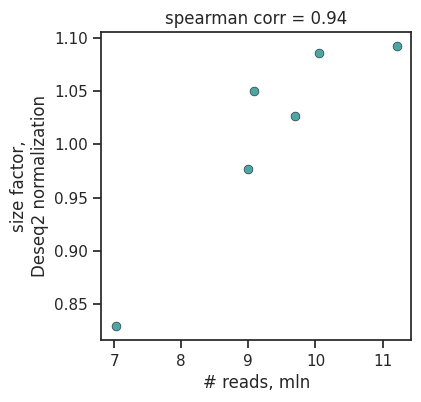

In [143]:
plot_size_factors(sfs_df,savefig_path='./tests/plots/library_size_vs_SF.png')

### Mean-Variance Modeling and Confidence Intervals

In [144]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_df, all_plot_data = model_mean_variance(
    norm_counts_df, 
    metadata_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion):")
print(regr_model_df)


Regression Model Parameters (Alpha/Dispersion):
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.025851
1  Treatment   QuantReg          var  0.034317


In [ ]:
# WARNING: param values should be very similar to the specified value of alpha (see above)!
# CURRENT status: it does not match

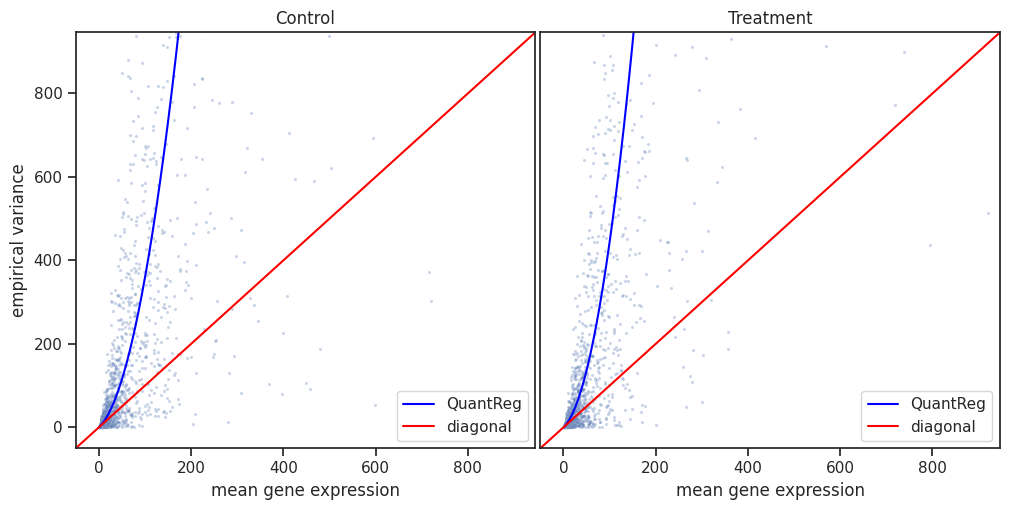

In [145]:
# Plot the diagnostic regression fits for variance within each condition
plot_mean_variance_diagnostics(
    all_plot_data, 
    savefig_path='./tests/plots/mean_variance_diagnostics.png'
)

## Sanity style normalization and quantification

In [187]:
# first, run Sanity without Empirical Bayes Shrinkage (as in the original paper)
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=pln_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=False,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2861 genes using 5 cores...
PASS 3: Finalizing Bayesian Posteriors...
Sanity normalization complete.


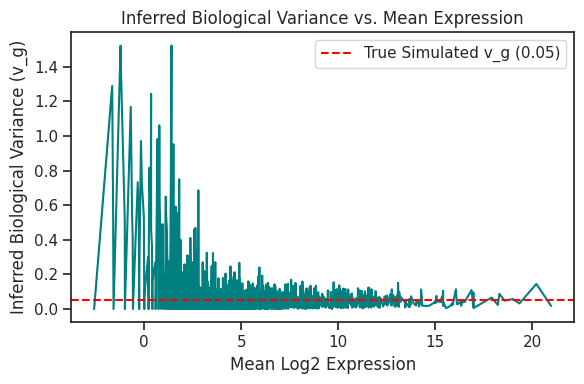

In [161]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.without_Empir_Bayes_Shrinkage.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

In [189]:
# now, run Sanity with Empirical Bayes Shrinkage that takes advantage of mean-variance relatioship across genes
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=pln_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=True,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2861 genes using 5 cores...
PASS 2: Applying Empirical Bayes Variance Shrinkage (LOWESS)...


AttributeError: 'numpy.ndarray' object has no attribute 'quantile'

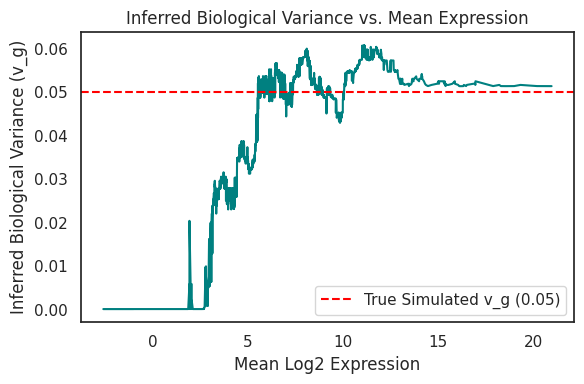

In [150]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

## Diagnostic plots for expression normalization confounders

these make more sense at larger number of replicates, like >15, because otherwise observed between-bioreplicate variance is mostly just technical noise

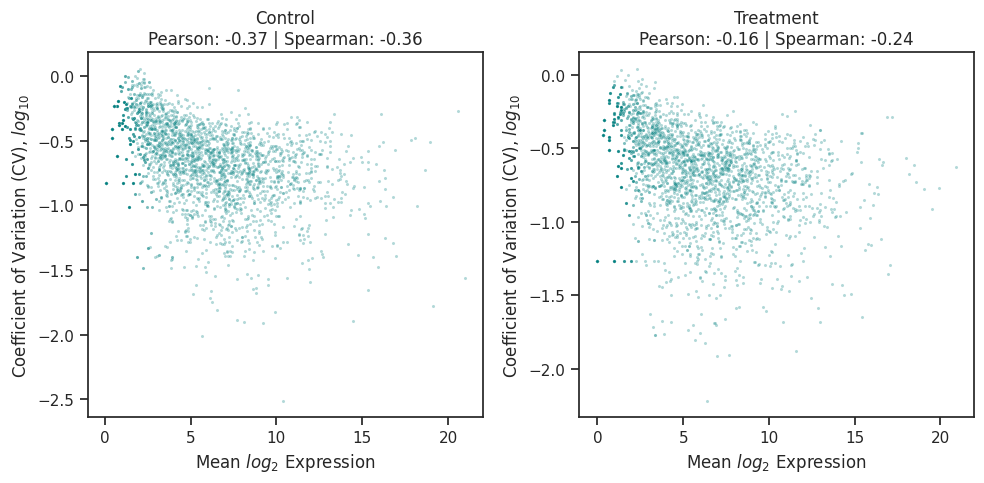

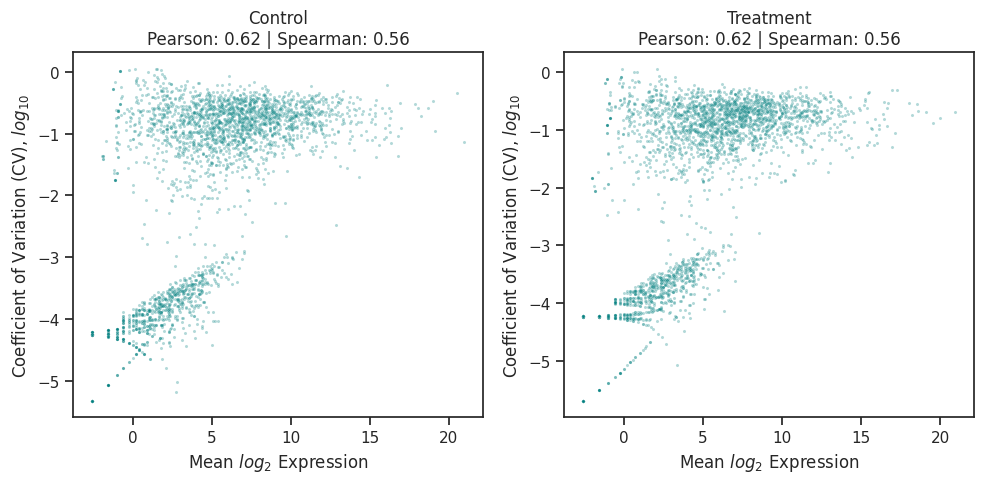

In [165]:
# 1. DESeq2 Mean vs CV (is_log2 = False because norm_counts is on raw scale)
deseq_plot_data = plot_mean_vs_cv(
    norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_deseq2.png', 
    is_log2=False
)
# 2. Sanity Mean vs CV (is_log2 = True to convert log2 back to raw for CV math)
sanity_plot_data = plot_mean_vs_cv(
    sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_sanity.png', 
    is_log2=True
)
# Sanity is highly effective at shrinking the variance of low-expression genes, 
# flattening the left side of the curve!

In [169]:
sanity_plot_data.head()

,gene,condition,log2_mean,log10_cv
0,Gene_2,Control,5.942195,-1.175468
1,Gene_3,Control,9.441383,-1.307925
2,Gene_4,Control,3.262705,-1.275052
3,Gene_5,Control,8.488752,-0.330716
4,Gene_6,Control,6.685005,-1.251326


In [177]:
indices_good = list(sanity_plot_data.loc[(sanity_plot_data['log10_cv']>(-2))&(sanity_plot_data['log2_mean']<2.4)]['gene'])

In [173]:
sanity_plot_data.loc[sanity_plot_data['log10_cv']<(-3.5)].head()

,gene,condition,log2_mean,log10_cv
9,Gene_11,Control,2.375565,-3.954866
11,Gene_13,Control,2.065128,-3.792714
18,Gene_20,Control,0.006210,-4.104559
21,Gene_23,Control,3.706751,-3.933541
30,Gene_32,Control,-2.578722,-4.234517


In [174]:
indices = list(sanity_plot_data.loc[sanity_plot_data['log10_cv']<(-3.5)]['gene'])
sanity_norm_counts_df.loc[indices].head()

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6
Gene_11,2.375603,2.375390,2.375701,2.375589,2.374784,2.375583
Gene_13,2.065371,2.064911,2.065101,2.064811,2.065320,2.065094
Gene_20,0.006099,0.006203,0.006323,0.006213,0.006197,0.006212
Gene_23,3.706825,3.706867,3.706560,3.707293,3.705784,3.706556
Gene_32,-2.578773,-2.578635,-2.578784,-2.578778,-2.578781,-2.578778


In [175]:
pln_counts_df.loc[indices].head()

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6
Gene_11,5,5,8,6,1,6
Gene_13,5,3,5,2,6,4
Gene_20,0,1,2,1,1,1
Gene_23,11,15,15,17,8,12
Gene_32,0,1,0,0,0,0


In [178]:
sanity_norm_counts_df.loc[indices_good].head()

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6
Gene_8,0.378885,0.551304,1.418780,0.300674,0.535847,1.093252
Gene_17,1.529708,2.870929,-0.281221,3.286623,1.128236,-0.101779
Gene_24,1.210801,0.788100,0.580757,0.469418,0.611764,0.806463
Gene_36,2.146934,2.072431,2.050020,2.248187,2.165506,2.048081
Gene_39,-1.508929,0.957688,-1.709974,-1.609782,-1.658904,-1.613729


In [179]:
pln_counts_df.loc[indices_good].head()

,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6
Gene_8,0,1,5,0,1,3
Gene_17,2,8,0,10,2,0
Gene_24,4,2,1,0,1,2
Gene_36,4,3,3,8,6,2
Gene_39,0,3,0,0,0,0


In [182]:
sanity_vg_df.loc[indices].head()

,inferred_v_g,raw_v_g
Gene_11,0.0001,0.0001
Gene_13,0.0001,0.0001
Gene_20,0.0001,0.0001
Gene_23,0.0001,0.0001
Gene_32,0.0001,0.0001


In [181]:
sanity_vg_df.loc[indices_good].head()

,inferred_v_g,raw_v_g
Gene_8,0.259603,0.259603
Gene_17,1.523315,1.523315
Gene_24,0.142878,0.142878
Gene_36,0.025468,0.025468
Gene_39,1.358550,1.358550


In [ ]:
sanity_means_df, sanity_errors_df, sanity_vg_df

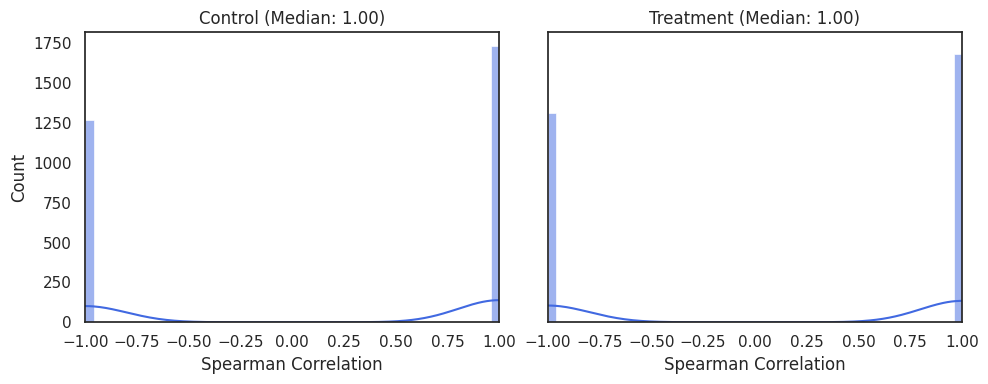

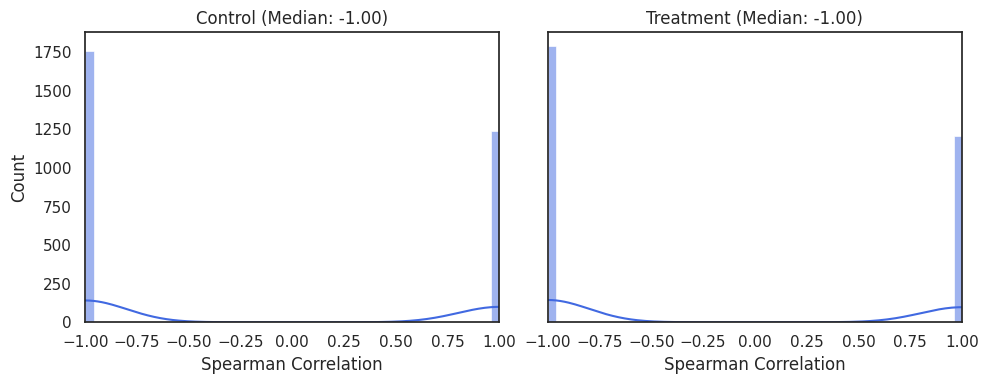

In [51]:
# 1. DESeq2 library size correction checks
plot_expr_vs_libsize_correlation(
    counts_df, norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/libsize_corr_deseq2.png',
    method='spearman', separate_conditions=True
)
# 2. Sanity library size correction checks
plot_expr_vs_libsize_correlation(
    counts_df, sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/libsize_corr_sanity.png',
    method='spearman', separate_conditions=True
)

## Plottting expression of individual genes with confidence intervals

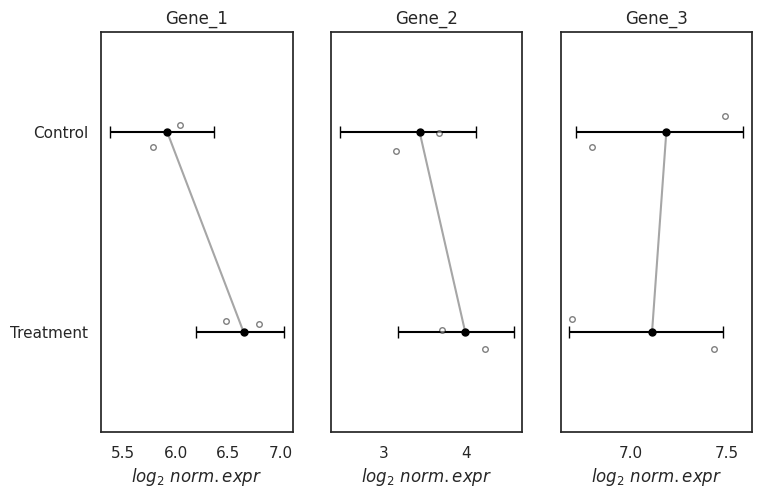

In [54]:
# Select specific genes of interest to visualize their differential expression
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

# Plot log2 expression with exact Negative Binomial confidence intervals
plot_gene_expression_with_ci(
    norm_counts_df, 
    metadata_df, 
    selected_genes, 
    regr_model_df, 
    savefig_path='./tests/plots/deseq_expression_ci.png',
    sample_col='sample', 
    cond_col='condition'
)

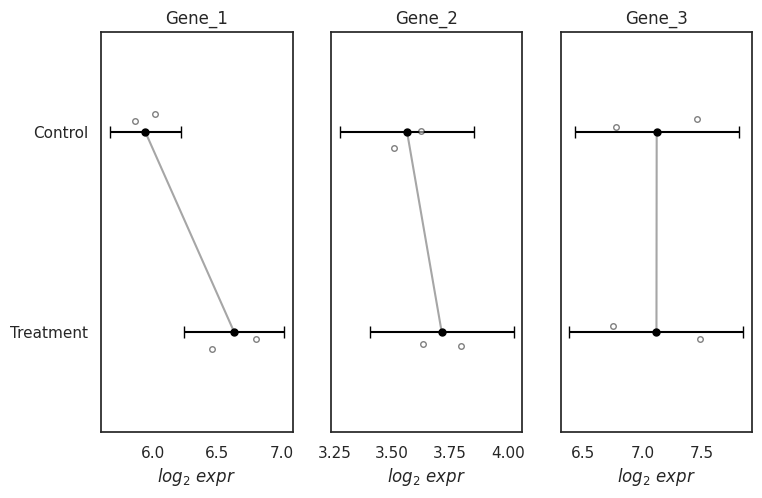

In [52]:
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

plot_sanity_gene_expression_with_ci(
    sample_norm_df=sanity_norm_counts_df, 
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    savefig_path='./tests/plots/sanity_expression_ci.png'
)

In [38]:
sanity_errors_df.head()

,Control,Treatment
Gene_1,0.140556,0.197406
Gene_2,0.148464,0.158664
Gene_3,0.353321,0.374556
Gene_4,0.123279,0.066133
Gene_5,0.192453,0.270254


In [36]:
sanity_norm_counts_df.head()

,Sample_1,Sample_2,Sample_3,Sample_4
Gene_1,5.862259,6.018788,6.802866,6.460013
Gene_2,3.622277,3.505540,3.795402,3.631737
Gene_3,7.461125,6.773632,7.480359,6.750491
Gene_4,10.890683,10.648692,11.023000,11.147782
Gene_5,3.852564,3.647221,3.580714,4.010850
